<a href="https://colab.research.google.com/github/AyatM711/CodVeda-_Intership/blob/main/level_One.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---------------------------------------
###Task One :
###1.Data Cleaning and Preprocessing
---------------------------------------
After Editing the CSV file in Excel and adding headers to the coloumns and seperate the values
the header coloumns and what each represent :
| Column    | Meaning                             |
| --------- | ----------------------------------- |
| CRIM      | Per-capita crime rate               |
| ZN        | Proportion of residential land      |
| INDUS     | Non-retail business land proportion |
| CHAS      | Charles River dummy variable        |
| NOX       | Nitric oxide concentration          |
| RM        | Average number of rooms             |
| AGE       | Proportion of older buildings       |
| DIS       | Distance to employment centres      |
| RAD       | Accessibility to radial highways    |
| TAX       | Property-tax rate                   |
| PTRATIO   | Pupil-teacher ratio                 |
| B         | Population-related index            |
| LSTAT     | Lower-status population percentage  |
| MEDV      | Median house value                  |




In [ ]:
#Import the important libraries
import pandas as pd
import numpy as np

# 1. Load the dataset using pandas
file_name = '4) house Prediction Data Set.csv'
df = pd.read_csv(file_name)

print(f"Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 5 rows:")
display(df.head())


Initial Shape: 506 rows, 14 columns

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


###2. Inspect Data Types and Missing Values


In [ ]:

print(df.info())

print("\nMissing Values Count Per Column:")
missing_vals = df.isnull().sum()
print(missing_vals)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     452 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB
None

Missing Values Count Per Column:
CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV       54


#### 3. Handle Duplicate Rows

In [ ]:
duplicates_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed! New Shape: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("No duplicates to remove.")


Duplicate rows found: 0
No duplicates to remove.


#### 4. Handle Missing Values (Imputation)

In [ ]:

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Impute numerical missing values using Median (handles outliers well)
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")

# Impute categorical missing values using Mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

if missing_vals.sum() == 0:
    print("No missing values detected in the initial dataset.")

Filled missing values in numerical column 'MEDV' with median: 21.95


###5. Standardize Data Formats

In [ ]:

# Clean text/categorical columns (remove leading/trailing spaces, capitalize properly)
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
print("Standardized text values (stripped extra spaces & unified casing).")

# Convert date column to standard datetime format if present
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    print("Converted 'date' column to standard datetime format.")

Standardized text values (stripped extra spaces & unified casing).


### 6. Final Data Summary

In [ ]:

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total remaining missing values: {df.isnull().sum().sum()}")



Final Shape: 506 rows, 14 columns
Total remaining missing values: 0


--------------------------------------------------------
###**Task 2:**
###Exploratory Analysis (EDA)
--------------------------------------------------------

Calculation of  summary statistics
*  mean
*  median
* mode
*  standard deviation



In [ ]:
#Import the requierd libraries for this part
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

# Calculate summary statistics
summary_statistics = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

# Display the results
display(summary_statistics.round(3))

,Mean,Median,Mode,Standard Deviation
CRIM,1.269,0.145,0.000,2.399
ZN,13.295,0.000,0.000,23.049
INDUS,9.205,6.960,18.100,7.170
CHAS,0.141,0.000,0.000,0.313
NOX,1.101,0.538,0.538,1.647
RM,15.680,6.322,100.000,27.220
AGE,58.745,65.250,100.000,33.104
DIS,6.173,3.926,24.000,6.476
RAD,78.063,5.000,5.000,203.542
TAX,339.318,307.000,666.000,180.670


**Data Distirbuation Visualization using Histogram**

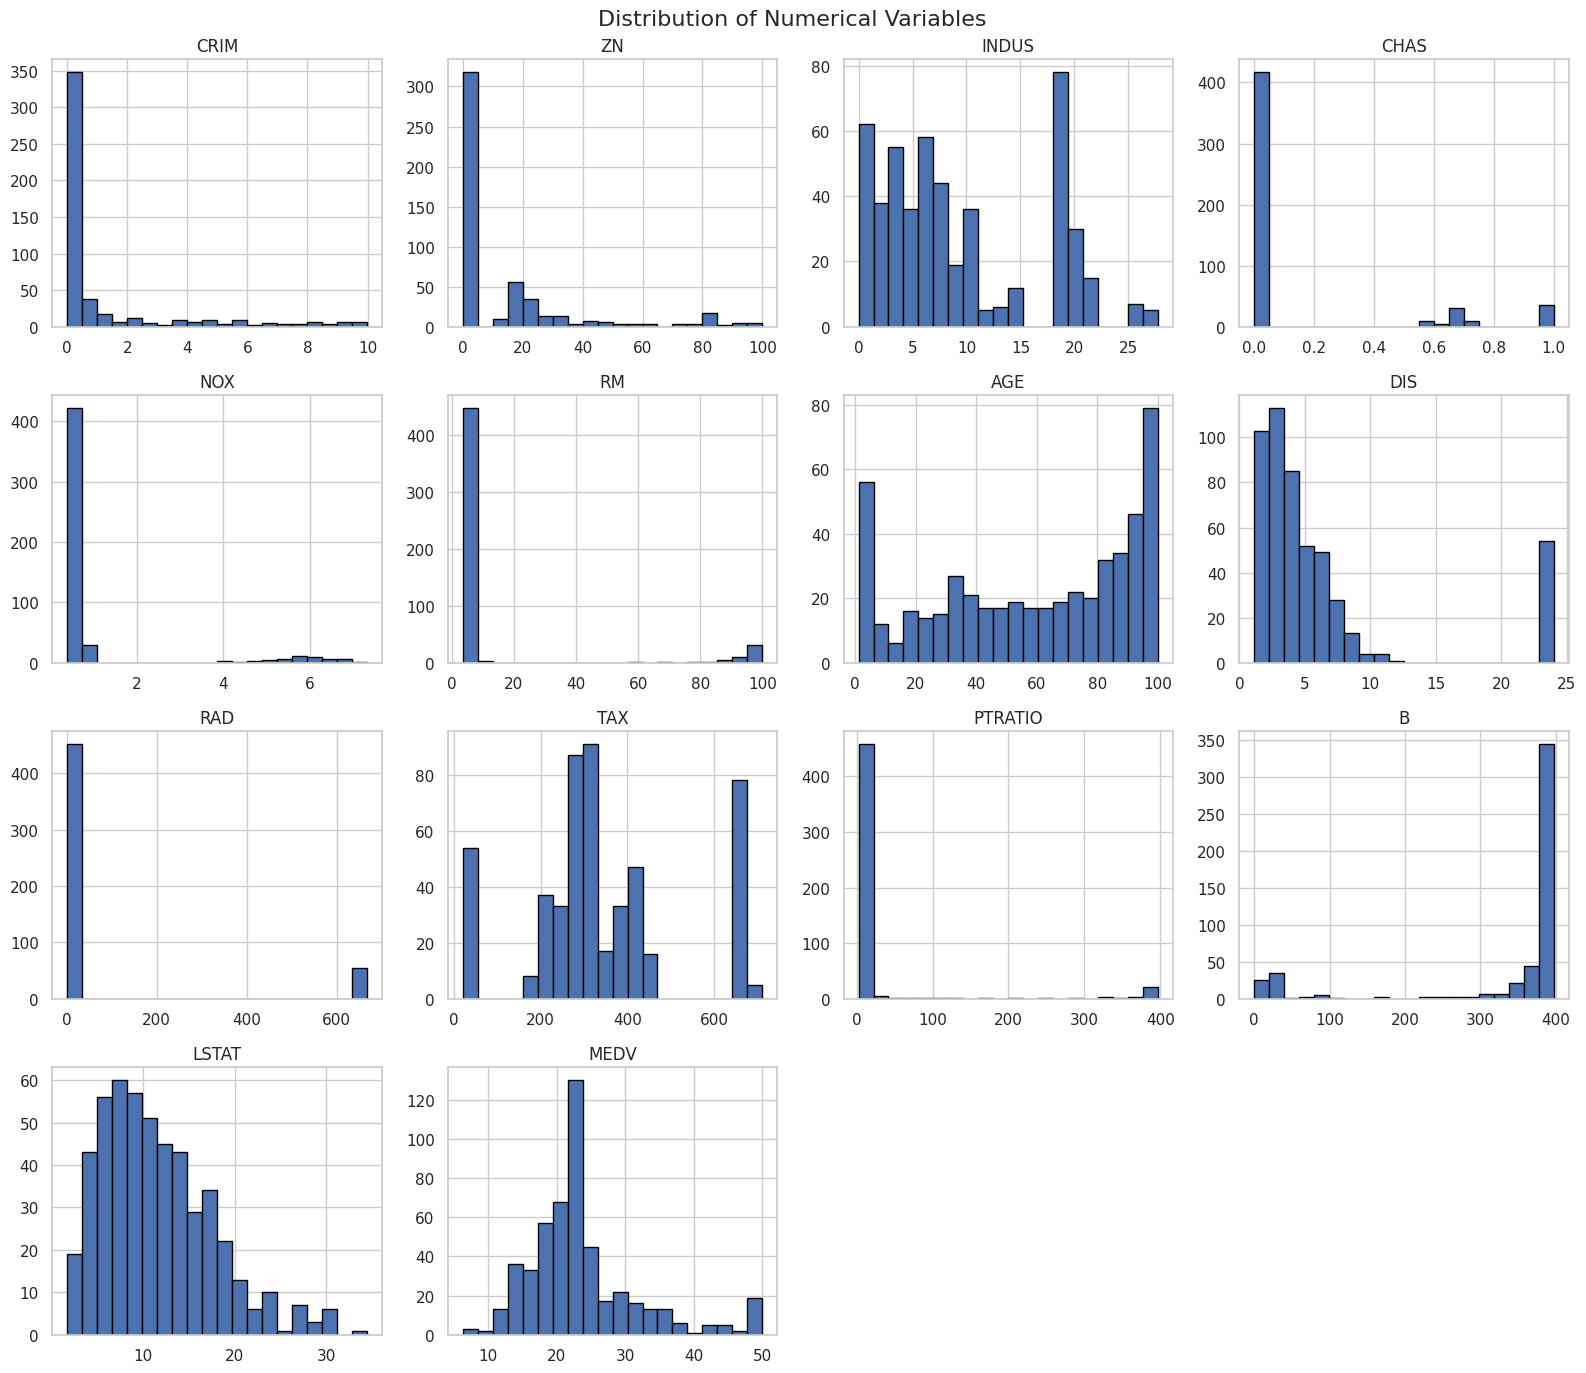

In [ ]:
# Create histograms for all numerical variables
df[numerical_columns].hist(
    figsize=(16, 14),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

**Data Visualization using BOXPLOTS for Outlier Detection for ALL features**

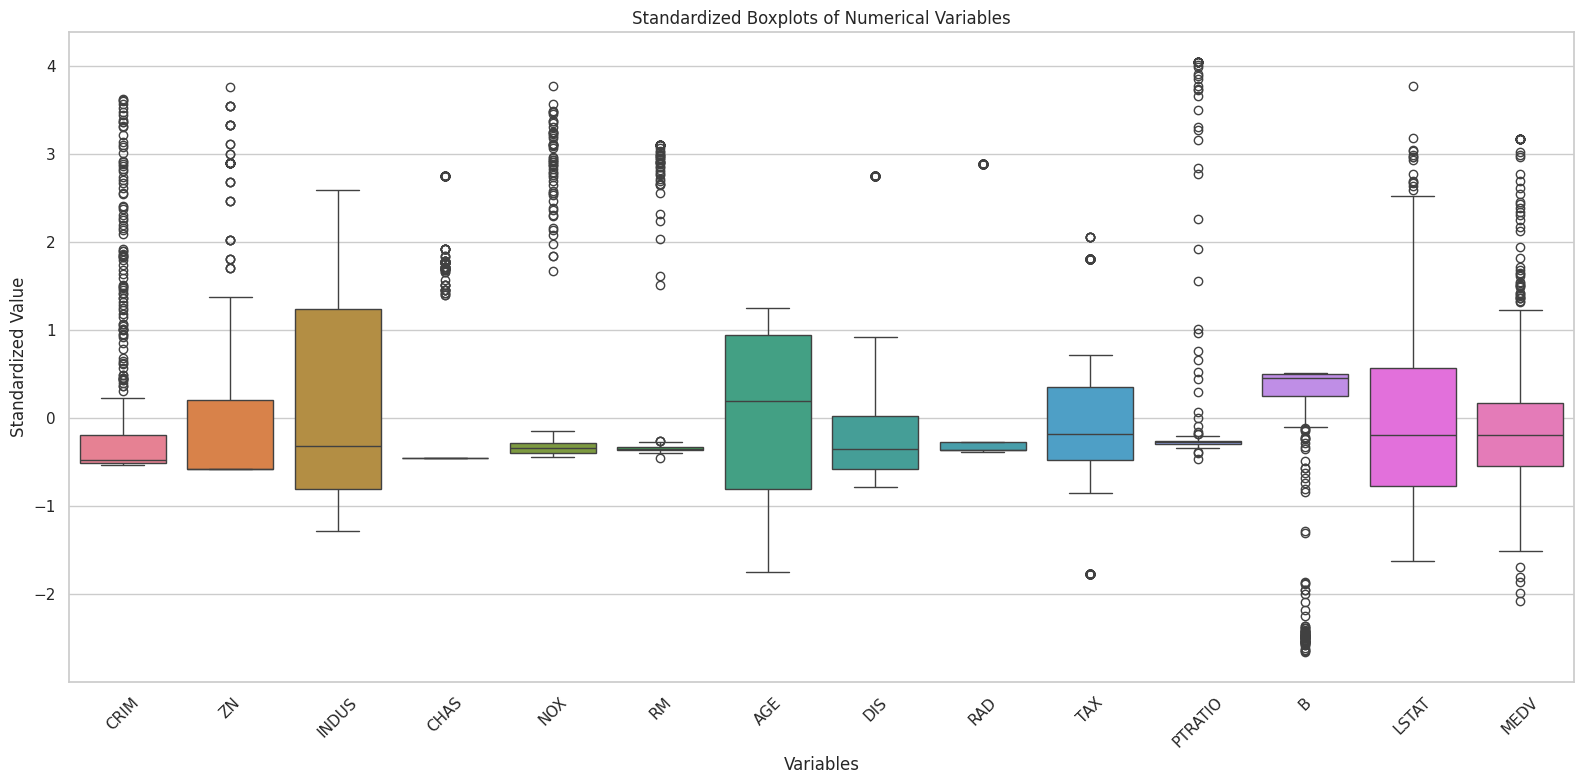

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical variables only for visualization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_columns])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numerical_columns
)

# Boxplot of standardized variables
plt.figure(figsize=(16, 8))

sns.boxplot(data=scaled_df)

plt.title("Standardized Boxplots of Numerical Variables")
plt.xlabel("Variables")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Data Visualization using Scatter Plot to look at relationship between variables**
# 1.Relationship between RM and MEDV

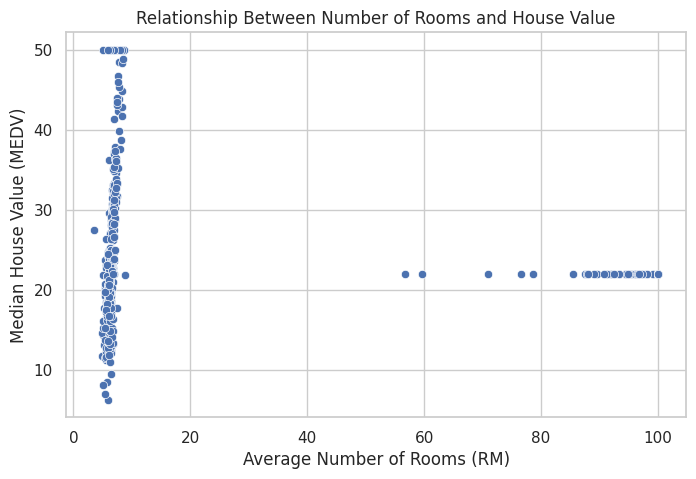

There is a positive relationship: houses with more rooms generally tend to have higher values.


In [ ]:
# RM versus MEDV
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='RM',
    y='MEDV'
)

plt.title("Relationship Between Number of Rooms and House Value")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.show()
print("There is a positive relationship: houses with more rooms generally tend to have higher values.")

# 2.Relationship between LSTAT and MEDV

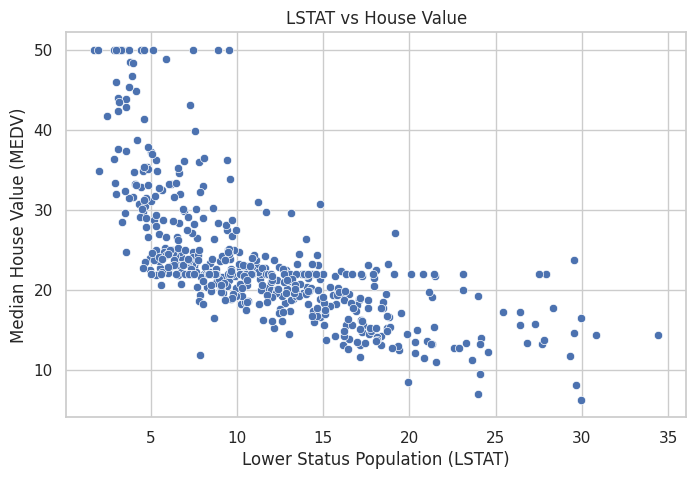

There is a strong negative relationship between LSTAT and MEDV


In [ ]:
# LSTAT versus MEDV
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='LSTAT',
    y='MEDV',

)

plt.title("LSTAT vs House Value")
plt.xlabel("Lower Status Population (LSTAT)")
plt.ylabel("Median House Value (MEDV)")
plt.show()
print("There is a strong negative relationship between LSTAT and MEDV")

#3.Relationship between CRIM and  MEDV

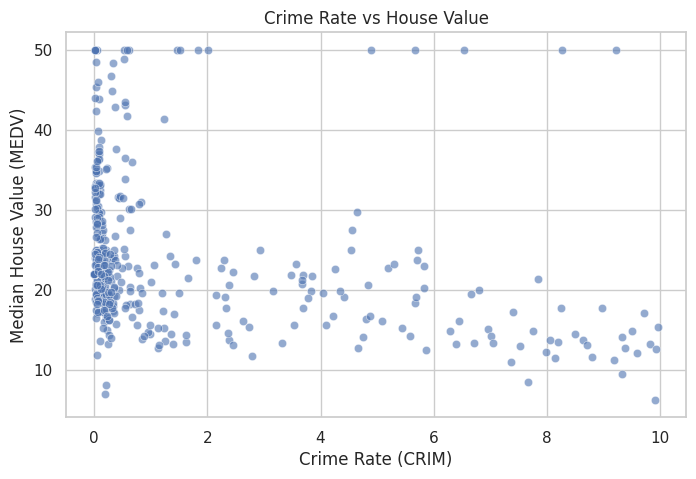

In [ ]:
# CRIM versus MEDV
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='CRIM',
    y='MEDV',
    alpha=0.6
)

plt.title("Crime Rate vs House Value")
plt.xlabel("Crime Rate (CRIM)")
plt.ylabel("Median House Value (MEDV)")
plt.show()

# Data Correlation Analysis
for this part I choose MEDV for the correlation analysis because it represents the median house value, which is the main target variable in the house prediction dataset,Analyzing its correlation with other features helps identify which variables have the strongest relationships with house prices and may be useful for prediction.
* Using Heatmap






In [ ]:
# Calculate correlation of every numerical variable with MEDV
medv_correlation = df[numerical_columns].corr()['MEDV'].sort_values(
    ascending=False
)

print("Correlation with MEDV:")
display(medv_correlation.round(3).to_frame(name="Correlation"))

Correlation with MEDV:


,Correlation
MEDV,1.000
ZN,0.325
B,0.194
CHAS,0.085
DIS,-0.021
RM,-0.049
PTRATIO,-0.065
RAD,-0.074
NOX,-0.087
AGE,-0.201


* Correlation using Bar chart :




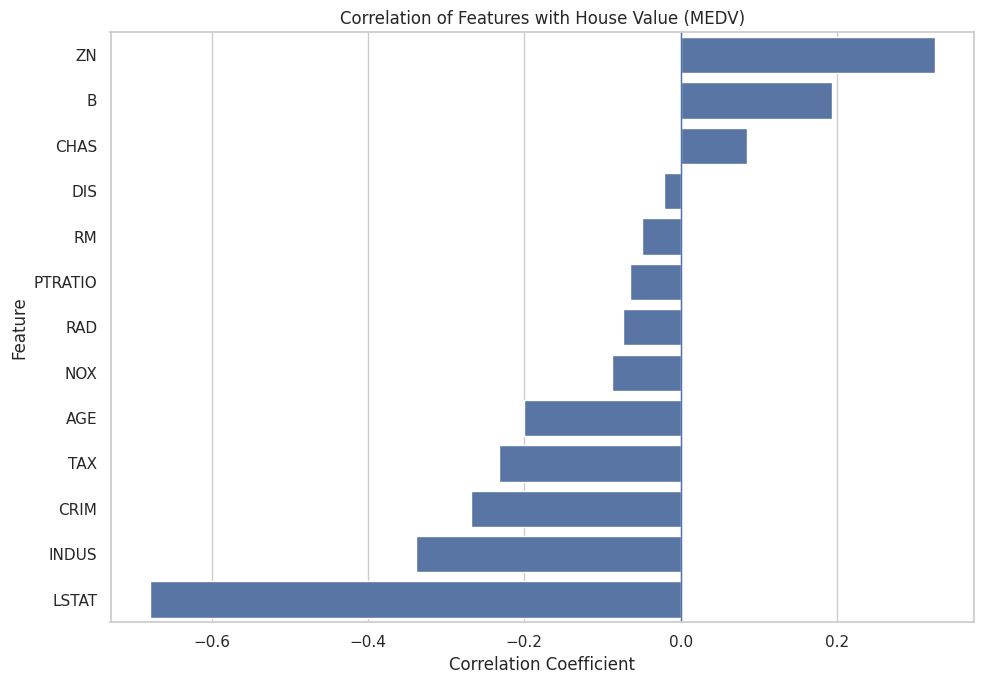

In [ ]:
# Remove MEDV itself from the correlation results
medv_corr_features = medv_correlation.drop('MEDV')

plt.figure(figsize=(10, 7))

sns.barplot(
    x=medv_corr_features.values,
    y=medv_corr_features.index
)

plt.title("Correlation of Features with House Value (MEDV)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
# Identify strong correlations between numerical variables
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

strong_correlations = (
    corr_pairs.stack()
    .reset_index()
)

strong_correlations.columns = ['Variable 1', 'Variable 2', 'Correlation']

strong_correlations['Absolute Correlation'] = (
    strong_correlations['Correlation'].abs()
)

strong_correlations = strong_correlations.sort_values(
    'Absolute Correlation',
    ascending=False
)

print("Top 10 strongest correlations:")
display(strong_correlations.head(10).round(3))

Top 10 strongest correlations:


,Variable 1,Variable 2,Correlation,Absolute Correlation
76,8,9,0.910,0.910
48,4,7,-0.769,0.769
26,2,4,0.764,0.764
63,6,7,-0.748,0.748
90,12,13,-0.738,0.738
47,4,6,0.731,0.731
31,2,9,0.721,0.721
29,2,7,-0.708,0.708
62,5,13,0.695,0.695
50,4,9,0.668,0.668


The final EDA Findings:


1. The dataset contains 506 observations and 14 numerical variables. The summary statistics show considerable variation between the variables, with some variables having relatively large standard deviations.

2. The histograms show that the numerical variables have different distributions. Some variables are approximately symmetric, while others show skewness and extreme values.

3. The boxplots identify potential outliers in several variables. These observations should be considered when developing predictive models because extreme values can influence statistical and machine learning results.

4. The scatter plot between RM and MEDV shows a positive relationship. The correlation between RM and MEDV is approximately 0.740, indicating a strong positive linear relationship. This suggests that houses with a larger average number of rooms generally have higher median values.

5. LSTAT has a strong negative correlation with MEDV of approximately -0.706. This indicates that higher values of LSTAT are generally associated with lower house values.

6. Other variables, including PTRATIO, INDUS, TAX, NOX, AGE, and CRIM, also show negative relationships with MEDV, although their strengths vary.

7. Overall, RM and LSTAT have the strongest relationships with MEDV among the numerical features. These variables may therefore be particularly useful when developing a model to predict house values.